<a href="https://colab.research.google.com/github/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Class%2016/Lab_16_High_Dimensional_GDP_Growth_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip -q install wbgapi

In [5]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
# !pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [6]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


In [7]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [8]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [9]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [10]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [11]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter
    and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray — Standardized training features
    y_train : np.ndarray — Training outcome (GDP growth)
    X_test  : np.ndarray — Standardized test features
    y_test  : np.ndarray — Test outcome
    cv      : int — Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV — Fitted model with optimal alpha
    test_r2     : float   — R² on held-out test set
    test_mse    : float   — MSE on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

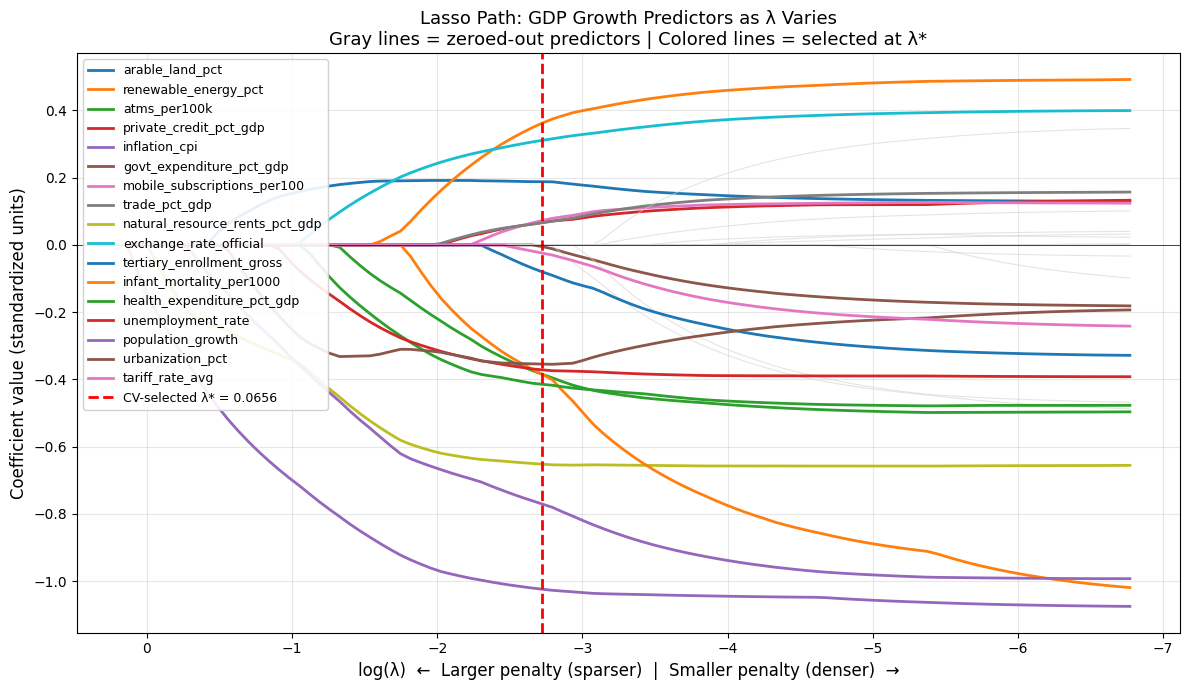

Lasso Path saved to lasso_path_gdp_growth.png


In [12]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,
    n_alphas=100,
)

optimal_alpha = lasso_cv_model.alpha_

fig, ax = plt.subplots(figsize=(12, 7))

active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [13]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],
        X_train.shape[1],
        np.sum(lasso_cv_model.coef_ != 0)
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • The other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • The other 11 are predictively redundant,
    not necessarily economically unimportant


Step 10:

Question 1:
The colleague is over-interpreting what Lasso does. A zero coefficient often reflects conditional predictive redundancy—if paved_roads_pct is highly correlated with other included variables (like infrastructure or development proxies), Lasso may drop it because its information is already captured elsewhere given the correlation structure of the data. This does not imply anything about the true causal relationship between paved roads and GDP growth; it only means the variable didn’t add additional predictive power conditional on the other predictors in the model.

Question 2:

For this dataset, I would prefer Ridge over Lasso. The training sample has a moderate number of predictors relative to observations ($p/n = 28/166$), so this is not an extreme high-dimensional setting where aggressive variable selection is essential. However, many of the WDI predictors are strongly correlated because they measure overlapping aspects of development. In that setting, Ridge is usually better because it shrinks coefficients continuously and distributes weight across correlated predictors, whereas Lasso may arbitrarily keep one proxy and drop another.

The model comparison results support this choice: Ridge achieved the best out-of-sample performance (test $R^2 = -0.051$, test MSE $= 4.691$) compared to Lasso (test $R^2 = -0.330$, test MSE $= 5.934$) and OLS (test $R^2 = -0.849$, test MSE $= 8.252$). Therefore, for this dataset, Ridge handles multicollinearity better and retains more predictive information than Lasso.


AI expansion:

In [16]:
# ============================================================
# INTERACTIVE REGULARIZATION DASHBOARD (matched to your notebook)
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# 1) Use the exact model names from your notebook
# ------------------------------------------------------------
ols_fitted = ols_model
ridge_fitted = ridge_cv
lasso_fitted = lasso_cv_model

feature_names = list(feature_names)

# ------------------------------------------------------------
# 2) Extract coefficient vectors from fitted models
# ------------------------------------------------------------
ols_coef = np.asarray(ols_fitted.coef_).ravel()
ridge_coef = np.asarray(ridge_fitted.coef_).ravel()
lasso_coef = np.asarray(lasso_fitted.coef_).ravel()

best_alpha = float(lasso_fitted.alpha_)

# ------------------------------------------------------------
# 3) Build a lambda grid for the interactive slider
#    We center it around the CV-chosen lambda from LassoCV
# ------------------------------------------------------------
lambda_min = max(best_alpha / 50, 1e-4)
lambda_max = best_alpha * 50
alphas_slider = np.logspace(np.log10(lambda_min), np.log10(lambda_max), 60)

log_alphas = np.log10(alphas_slider)

# ------------------------------------------------------------
# 4) For each lambda, refit Lasso and store:
#    - coefficient vector
#    - number of selected predictors
#    - train R²
#    - test R²
# ------------------------------------------------------------
coef_path = []
path_train_r2 = []
path_test_r2 = []
path_n_selected = []

for a in alphas_slider:
    model = Lasso(alpha=float(a), max_iter=20000)
    model.fit(X_train_scaled, y_train)

    coef_vec = np.asarray(model.coef_).ravel()
    coef_path.append(coef_vec)

    yhat_train = model.predict(X_train_scaled)
    yhat_test = model.predict(X_test_scaled)

    path_train_r2.append(r2_score(y_train, yhat_train))
    path_test_r2.append(r2_score(y_test, yhat_test))
    path_n_selected.append(int(np.sum(np.abs(coef_vec) > 1e-10)))

coef_path = np.array(coef_path)              # shape = (n_alphas, n_features)
path_train_r2 = np.array(path_train_r2)
path_test_r2 = np.array(path_test_r2)
path_n_selected = np.array(path_n_selected)

best_idx = int(np.argmin(np.abs(alphas_slider - best_alpha)))

# ------------------------------------------------------------
# 5) Create a 2-panel Plotly figure
#    Left: Lasso coefficient path + slider
#    Right: OLS vs Ridge vs Lasso coefficient comparison
# ------------------------------------------------------------
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.58, 0.42],
    horizontal_spacing=0.12,
    subplot_titles=(
        "Lasso Path with Interactive λ Slider",
        "Coefficient Comparison: OLS vs Ridge vs Lasso"
    )
)

# ------------------------------------------------------------
# 6) LEFT PANEL: add full coefficient paths
#    Each line = one predictor's coefficient as lambda changes
# ------------------------------------------------------------
for j, feat in enumerate(feature_names):
    fig.add_trace(
        go.Scatter(
            x=log_alphas,
            y=coef_path[:, j],
            mode="lines",
            name=feat,
            line=dict(width=1),
            opacity=0.45,
            hovertemplate=(
                f"Feature: {feat}<br>"
                "log10(λ): %{x:.3f}<br>"
                "Coefficient: %{y:.4f}<extra></extra>"
            ),
            showlegend=False
        ),
        row=1,
        col=1
    )

n_static_left = len(feature_names)

# ------------------------------------------------------------
# 7) Add slider-controlled traces:
#    - a vertical dashed line at current lambda
#    - markers for currently non-zero coefficients
#
# Plotly slider does not use a Python callback after rendering.
# Instead, each slider step updates trace visibility client-side.
# ------------------------------------------------------------
for i, a in enumerate(alphas_slider):
    coef_vec = coef_path[i]
    selected_mask = np.abs(coef_vec) > 1e-10
    selected_features = np.array(feature_names)[selected_mask]
    selected_y = coef_vec[selected_mask]
    selected_x = np.repeat(log_alphas[i], selected_mask.sum())

    # Vertical line for current lambda
    fig.add_trace(
        go.Scatter(
            x=[log_alphas[i], log_alphas[i]],
            y=[coef_path.min(), coef_path.max()],
            mode="lines",
            line=dict(width=3, dash="dash"),
            hoverinfo="skip",
            showlegend=False,
            visible=(i == best_idx)
        ),
        row=1,
        col=1
    )

    # Markers for currently selected (non-zero) predictors
    fig.add_trace(
        go.Scatter(
            x=selected_x,
            y=selected_y,
            mode="markers+text",
            text=selected_features,
            textposition="middle right",
            marker=dict(size=8),
            hovertemplate=(
                "Feature: %{text}<br>"
                "log10(λ): %{x:.3f}<br>"
                "Coefficient: %{y:.4f}<extra></extra>"
            ),
            showlegend=False,
            visible=(i == best_idx)
        ),
        row=1,
        col=1
    )

# ------------------------------------------------------------
# 8) RIGHT PANEL: grouped bar chart
#    Coefficients come directly from .coef_ of each fitted model
# ------------------------------------------------------------
fig.add_trace(
    go.Bar(
        x=feature_names,
        y=ols_coef,
        name="OLS",
        opacity=0.8
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Bar(
        x=feature_names,
        y=ridge_coef,
        name="Ridge",
        opacity=0.8
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Bar(
        x=feature_names,
        y=lasso_coef,
        name="Lasso",
        opacity=0.8
    ),
    row=1,
    col=2
)

# ------------------------------------------------------------
# 9) Build slider steps
#    Each step:
#    - keeps all path lines visible
#    - shows only one vertical line + one marker set
#    - keeps the 3 bar-chart traces visible
#    - updates the title with current lambda / R² / selected count
# ------------------------------------------------------------
n_total_traces = len(fig.data)
bar_trace_indices = list(range(n_total_traces - 3, n_total_traces))

steps = []
for i, a in enumerate(alphas_slider):
    visible = [False] * n_total_traces

    # Keep all static path lines visible
    for idx in range(n_static_left):
        visible[idx] = True

    # Show only the current line + marker traces
    current_line_idx = n_static_left + 2 * i
    current_marker_idx = n_static_left + 2 * i + 1
    visible[current_line_idx] = True
    visible[current_marker_idx] = True

    # Keep right-panel bar traces visible
    for idx in bar_trace_indices:
        visible[idx] = True

    title_text = (
        "Interactive Regularization Dashboard"
        f"<br><sup>"
        f"λ = {a:.6f} | "
        f"log10(λ) = {np.log10(a):.3f} | "
        f"Selected Predictors = {path_n_selected[i]} | "
        f"Train R² = {path_train_r2[i]:.3f} | "
        f"Test R² = {path_test_r2[i]:.3f}"
        f"</sup>"
    )

    steps.append(
        dict(
            method="update",
            args=[
                {"visible": visible},
                {"title": title_text}
            ],
            label=f"{a:.4f}"
        )
    )

sliders = [
    dict(
        active=best_idx,
        currentvalue={"prefix": "Current λ: "},
        pad={"t": 40},
        steps=steps
    )
]

# ------------------------------------------------------------
# 10) Final layout formatting
# ------------------------------------------------------------
fig.update_layout(
    sliders=sliders,
    barmode="group",
    height=720,
    width=1500,
    title=(
        "Interactive Regularization Dashboard"
        f"<br><sup>"
        f"λ = {alphas_slider[best_idx]:.6f} | "
        f"log10(λ) = {np.log10(alphas_slider[best_idx]):.3f} | "
        f"Selected Predictors = {path_n_selected[best_idx]} | "
        f"Train R² = {path_train_r2[best_idx]:.3f} | "
        f"Test R² = {path_test_r2[best_idx]:.3f}"
        f"</sup>"
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0.58
    )
)

fig.update_xaxes(title_text="log10(λ)", row=1, col=1)
fig.update_yaxes(title_text="Coefficient Value", row=1, col=1)

fig.update_xaxes(title_text="Predictors", tickangle=60, row=1, col=2)
fig.update_yaxes(title_text="Coefficient Value", row=1, col=2)

fig.show()